## Setup

### Imports

In [1]:
%load_ext autoreload
%autoreload --print 3

In [2]:
import jax.random as jr
jr.KeyArray = jr.PRNGKey
import shape_norm

from shape_norm.io import loaders
from shape_norm.models import joint
from shape_norm import config
from shape_norm.models import instantiation, setup, pose, morph, util as model_util
from shape_norm import fitting
from shape_norm.fitting import em
from shape_norm.io import alignment, features
from shape_norm.io.armature import Armature
from shape_norm.fitting import methods
from shape_norm.fitting import scans
from shape_norm.pca import fit_with_center, CenteredPCA, PCAData
from shape_norm.io.dataset import PytreeDataset
from shape_norm.io.dataset_refactor import Dataset, SessionMetadata
from shape_norm.models.morph.lowrank_affine import LRAParams, model as lra_model
from shape_norm.viz import styles

from blscale_loader import loader, linear_skeletal as blscale_ls

from collections import defaultdict
from shape_norm.viz import util as vu
from scipy import spatial
import itertools as iit
import matplotlib.colors as mpl_col
from sklearn.linear_model import LogisticRegression
import matplotlib as mpl
from sklearn import metrics
import numpy as np
import re
from scipy.spatial import distance
import jax
import jax.numpy as jnp
from pprint import pprint
import numpy.linalg as la
from ruamel.yaml import YAML
import scipy.stats
from pathlib import Path
from cmap import Colormap
from bidict import bidict
import matplotlib as mpl
import joblib as jl
import matplotlib.pyplot as plt
from tqdm import tqdm, trange
import itertools as iit
import pandas as pd
import seaborn as sns


### supporting funcs


#### General supporting funcs

In [3]:
from supporting_funcs.keypoint_data import _bone_lengths, cos, _joint_angles

# _bone_lengths = lambda kpts, arms: jnp.linalg.norm(
#     kpts[..., arms.bones[:, 0], :] - kpts[..., arms.bones[:, 1], :], axis=-1
# )
# cos = lambda a, b, **k: (a * b).sum(**k) / jnp.sqrt((a * a).sum(**k) * (b * b).sum(**k))
# _joint_angles = lambda kpts, joint_kp_ixs: np.array([(180/np.pi) * np.arccos(np.clip(cos(
#     kpts[:, c, :] - kpts[:, p, :],
#     kpts[:, g, :] - kpts[:, p, :],
# axis = -1), -1, 1)) for c, p, g in joint_kp_ixs]).T

In [4]:
# import jax.random as jr

# jr.KeyArray = jr.PRNGKey
# import numpy as np
# import numpy.linalg as la
# from scipy.signal import savgol_filter
# import matplotlib.colors as mpl_col

# # calculus and statistics
# val_and_deriv = lambda x, w=5: (x, savgol_filter(x, w, polyorder=1, deriv=1, axis=0))
# vel_acc = lambda x, w=5: val_and_deriv(  # x, shape (t, ..., spatial)
#     la.norm(savgol_filter(x, w, polyorder=1, deriv=1, axis=0), axis=-1), w=w
# )
# cos = lambda a, b: np.clip(
#     (a * b).sum(axis=-1) / (la.norm(a, axis=-1) * la.norm(b, axis=-1)), -1, 1
# )
# cov = lambda x, y: (x * y).mean(axis=-1) - x.mean(axis=-1) * y.mean(axis=-1)
# corr = lambda a, b: cov(a, b) / np.sqrt(cov(a, a) * cov(b, b))
# coef = lambda a, b: cov(a, b) / cov(a, a)
# windowed_cov = lambda x, y, w: cov(
#     *np.lib.stride_tricks.sliding_window_view(
#         np.pad(
#             np.stack([x, y]),
#             ((0, 0), (int(np.ceil((w - 1) / 2)), int(np.floor((w - 1) / 2)))),
#         ),
#         window_shape=w,
#         axis=1,
#     )
# )

# # skeleton functions
# bone_locations = lambda keypts, armature: np.stack(
#     [
#         keypts[..., armature.bones[i, 1], :] - keypts[..., armature.bones[i, 0], :]
#         for i in range(len(armature.bones))
#     ],
#     axis=-2,
# )
# bone_lengths = lambda keypts, armature: la.norm(
#     bone_locations(keypts, armature), axis=-1
# )
# elevation = (
#     lambda arr: (
#         np.arccos(cos(arr, arr * np.array([1, 1, 0])[None])) * np.sign(arr[:, 2])
#     )
#     * 180
#     / np.pi
# )
# rotation = (
#     lambda arr: (
#         np.arccos(cos(arr, arr * np.array([1, 0, 1])[None])) * np.sign(arr[:, 1])
#     )
#     * 180
#     / np.pi
# )
# short_bone_names = lambda armature: [
#     armature.keypoint_names[int(i)] for i, j in armature.bones
# ]
# long_bone_names = lambda armature: [
#     f"{armature.keypoint_names[int(i)]}-{armature.keypoint_names[int(j)]}"
#     for i, j in armature.bones
# ]


# # model manipulation
# def lra_anchor_poses(params, magnitudes=90):
#     L = params.n_dims

#     if isinstance(magnitudes, (int, float)):
#         magnitudes = magnitudes * np.ones(L)

#     # (n_bodies, n_dims, 1)
#     anchors = (params.offset + params.offset_updates).reshape(params.n_bodies, -1, 1)
#     # (n_bodies, n_dims, n_modes + 1)
#     anchors = np.concatenate(
#         [
#             anchors,
#             anchors + magnitudes[None, None] * (params.modes + params.mode_updates),
#         ],
#         axis=-1,
#     )

#     return anchors


# def lra_induced_anchors(dataset, config, params, magnitudes, n_neighbors):
#     from kpsn.models import util
#     from kpsn.models.morph.lowrank_affine import model

#     anchors = lra_anchor_poses(params, magnitudes)
#     ref_data = dataset.get_session(dataset.ref_session)
#     ref_anchor_diff = (
#         ref_data[..., None]
#         - anchors[None, dataset.session_body_id(dataset.ref_session)]
#     )
#     near_anchors_ix = np.array(
#         [
#             la.norm(ref_anchor_diff[..., j], axis=(-1)).argsort(axis=0)[:n_neighbors]
#             for j in range(anchors.shape[-1])
#         ]
#     )
#     induced_anchors = util.induced_reference_keypoints(
#         dataset,
#         config,
#         model,
#         params,
#         include_reference=True,
#         ref_frames=ref_data[near_anchors_ix].mean(axis=1),
#     )

#     return induced_anchors



# ### plotting


# def plot_mouse_3d(
#     frame,
#     ax,
#     armature,
#     elev,
#     rot,
#     colors=None,
#     bone_n=40,
#     point_size=10,
#     line_size=2,
#     line_colors=None,
#     point_kws={},
#     line_kws={},
#     boundary=True,
#     set_aspect=True,
#     label = None
# ):
#     """all keys in point kws should be present in line kws"""

#     if colors is None:
#         import seaborn as sns

#         colors = mpl_col.to_rgba(sns.color_palette("Blues", 10 + frame.shape[0])[10:])
#     if line_colors is None:
#         line_colors = colors
#     colors = np.array([mpl_col.to_rgba(x) for x in colors])
#     line_colors = np.array([mpl_col.to_rgba(x) for x in line_colors])
#     point_kws = {
#         **dict(
#             linewidths=np.array([0] * armature.n_kpts),
#         ),
#         **point_kws,
#     }
#     line_kws = {
#         **dict(
#             linewidths=np.array([0] * armature.n_kpts),
#         ),
#         **line_kws,
#     }

#     # --- points

#     x, y, z, c, s = [], [], [], [], []
#     x.append(frame[:, 0])
#     y.append(frame[:, 1])
#     z.append(frame[:, 2])
#     c.append(colors)
#     s.append([point_size] * armature.n_kpts)
#     kws = {k: [] for k in point_kws}
#     concat_keys = []
#     for k, v in point_kws.items():
#         if np.array(v).shape[:1] == (armature.n_kpts,):
#             concat_keys.append(k)
#             kws[k].append(v)
#         else:
#             kws[k] = v

#     x = np.concatenate(x)
#     y = np.concatenate(y)
#     z = np.concatenate(z)
#     c = np.concatenate(c)
#     s = np.concatenate(s)
#     for k, v in kws.items():
#         if k in concat_keys:
#             kws[k] = np.concatenate(kws[k])
#     point_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

#     # --- "lines"

#     x, y, z, c, s = [], [], [], [], []
#     kws = {k: [] for k in line_kws}
#     concat_keys = []
#     for i, (ch, pa) in enumerate(armature.bones):
#         x.append(np.linspace(frame[ch, 0], frame[pa, 0], bone_n)[1:-1])
#         y.append(np.linspace(frame[ch, 1], frame[pa, 1], bone_n)[1:-1])
#         z.append(np.linspace(frame[ch, 2], frame[pa, 2], bone_n)[1:-1])
#         c.append(np.full([bone_n - 2, 4], line_colors[ch]))
#         s.append(np.full([bone_n - 2], line_size))
#         for k, v in line_kws.items():
#             if np.array(v).shape[:1] == (armature.n_kpts,):
#                 concat_keys.append(k)
#                 kws[k].append(np.full((bone_n - 2,) + np.array(v).shape[1:], v[ch]))
#             else:
#                 kws[k] = v
#     x = np.concatenate(x)
#     y = np.concatenate(y)
#     z = np.concatenate(z)
#     c = np.concatenate(c)
#     s = np.concatenate(s)
#     for k, v in kws.items():
#         if k in concat_keys:
#             kws[k] = np.concatenate(kws[k])

#     line_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

#     ax.view_init(elev, rot)

#     ax.grid(False)
#     ax.xaxis.pane.fill = False
#     ax.yaxis.pane.fill = False
#     ax.zaxis.pane.fill = False
#     ax.xaxis.set_ticks([])
#     ax.yaxis.set_ticks([])
#     ax.zaxis.set_ticks([])
#     if not boundary:
#         ax.xaxis.pane.set_linewidth(0)
#         ax.yaxis.pane.set_linewidth(0)
#         ax.zaxis.pane.set_linewidth(0)
#         ax.xaxis.line.set_linewidth(0)
#         ax.yaxis.line.set_linewidth(0)
#         ax.zaxis.line.set_linewidth(0)

    
#     # use a.set_box_aspect to make the aspect equal to the ratio of the limits
#     if set_aspect:
#         xrng = np.ptp(ax.get_xlim())
#         yrng = np.ptp(ax.get_ylim())
#         zrng = np.ptp(ax.get_zlim())
#         ax.set_box_aspect([xrng, yrng, zrng])

#     return point_artist, line_artist

#### Dataset supporting funcs

In [5]:
from supporting_funcs.keypoint_data import mouse_data_armature_meta, _with_match, _name_func

# def mouse_data_armature_meta():
#     """Organize metadata on keypoints and skeleton of mouse data."""
#     names = [
#         'shldr', 'back', 'hips', 't_base','t_tip', 'head',
#         'l_ear', 'r_ear', 'nose', 'lr_knee', 'lr_foot',
#         'rr_knee', 'rr_foot', 'lf_foot', 'rf_foot']
#     parents = dict(zip(names, [
#         'back', 'hips', None, 'hips', 't_base', 'shldr',
#         'head', 'head', 'head', 'hips', 'lr_knee',
#         'hips', 'rr_knee', 'shldr', 'shldr']))
#     keypt_ix = lambda name: names.index(name)
#     bones = np.array([(keypt_ix(c), keypt_ix(p)) for c, p in parents.items() if p])
#     root = keypt_ix("shldr")
#     bones = blscale_ls.reroot(bones, root)
#     bones = bones[np.argsort(bones[:, 0])]
#     return names, parents, bones, root

# _with_match = lambda test, pattern, f: f(m) if (m := re.search(pattern, test)) else None
# _name_func = lambda path, *a: _with_match(
#     path, r"(?:/.*)+/\d{2}_\d{2}_\d{2}_(\d+wk_m\d+)\.npy",
#     lambda m: f"{m.group(1)}")


# --- deprecated

# def load_all_mouse_sessions(age_whitelist = None):
#     data_root = '../../../../data_explore/data'

#     # Create mapping of session names (ie 3wk_m0) to keypoint data paths

#     modata_npy_name_func = (lambda path, *a:
#         match.group(1) if ((match := re.search(r"\d{2}_\d{2}_\d{2}_(\d+wk_m\d+)\.npy", path)) is not None) else None)
#     session_paths = dict(filter(lambda x: x[0] is not None, [(modata_npy_name_func(m), str(Path(data_root) / m)) for m in os.listdir(data_root)]))
#     # throw out 9-12 week
#     session_ages = {s: s.split('_')[0].strip('wk') for s in session_paths}
#     ages = set(session_ages.values())
#     if age_whitelist is not None:
#         ages = list(filter(lambda x: x in age_whitelist, ages))
#     session_paths = {s: p for s, p in session_paths.items() if session_ages[s] in ages}
#     session_bodies = {s: f'body-{session_ages[s]}wk' for s in session_paths}
#     names, parents, _, _ = mouse_data_armature_meta()

#     age_dates =  {
#         "3" : "10_11_22",
#         "5" : "10_24_22",
#         "7" : "10_24_22",
#         "24": "11_03_22",
#         "52" : "11_03_22",
#         "72" : "10_14_22",
#     }

#     print("sessions:", session_paths.keys())

#     sesssion_kps = {
#         s: np.load(p) for s, p in session_paths.items()
#     }

#     project_config_kws = {
#         "session_names": list(sesssion_kps.keys()),
#         "bodies": session_bodies,
#         "keypoint_names": names,
#         "keypoint_parents": parents,
#     }

#     return project_config_kws, sesssion_kps

#### plotting supporting funcs

In [6]:
from supporting_funcs.plotting import getc, plot_mouse_3d, plotdrop, _plotdrop

# def getc(spec):
#     try:
#         from cmap import Colormap, Color
#         try:
#             return Color(spec)
#         except ValueError as e:
#             stop = spec.split(':')[-1]
#             if stop.startswith('.'):
#                 stop = float(stop)
#             else:
#                 stop = int(stop)
#             cm = Colormap(':'.join(spec.split(':')[:-1]))
#             return cm(stop)
#     except ImportError:
#         return spec

# def plot_mouse_3d(
#     frame,
#     ax,
#     armature,
#     elev,
#     rot,
#     colors=None,
#     bone_n=40,
#     point_size=10,
#     line_size=2,
#     line_colors=None,
#     point_kws={},
#     line_kws={},
#     boundary=True,
#     set_aspect=True,
#     label = None
# ):
#     """all keys in point kws should be present in line kws"""

#     if colors is None:
#         import seaborn as sns

#         colors = mpl_col.to_rgba(sns.color_palette("Blues", 10 + frame.shape[0])[10:])
#     if line_colors is None:
#         line_colors = colors
#     colors = np.array([mpl_col.to_rgba(x) for x in colors])
#     line_colors = np.array([mpl_col.to_rgba(x) for x in line_colors])
#     point_kws = {
#         **dict(
#             linewidths=np.array([0] * armature.n_kpts),
#         ),
#         **point_kws,
#     }
#     line_kws = {
#         **dict(
#             linewidths=np.array([0] * armature.n_kpts),
#         ),
#         **line_kws,
#     }

#     # --- points

#     x, y, z, c, s = [], [], [], [], []
#     x.append(frame[:, 0])
#     y.append(frame[:, 1])
#     z.append(frame[:, 2])
#     c.append(colors)
#     s.append([point_size] * armature.n_kpts)
#     kws = {k: [] for k in point_kws}
#     concat_keys = []
#     for k, v in point_kws.items():
#         if np.array(v).shape[:1] == (armature.n_kpts,):
#             concat_keys.append(k)
#             kws[k].append(v)
#         else:
#             kws[k] = v

#     x = np.concatenate(x)
#     y = np.concatenate(y)
#     z = np.concatenate(z)
#     c = np.concatenate(c)
#     s = np.concatenate(s)
#     for k, v in kws.items():
#         if k in concat_keys:
#             kws[k] = np.concatenate(kws[k])
#     point_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

#     # --- "lines"

#     x, y, z, c, s = [], [], [], [], []
#     kws = {k: [] for k in line_kws}
#     concat_keys = []
#     for i, (ch, pa) in enumerate(armature.bones):
#         x.append(np.linspace(frame[ch, 0], frame[pa, 0], bone_n)[1:-1])
#         y.append(np.linspace(frame[ch, 1], frame[pa, 1], bone_n)[1:-1])
#         z.append(np.linspace(frame[ch, 2], frame[pa, 2], bone_n)[1:-1])
#         c.append(np.full([bone_n - 2, 4], line_colors[ch]))
#         s.append(np.full([bone_n - 2], line_size))
#         for k, v in line_kws.items():
#             if np.array(v).shape[:1] == (armature.n_kpts,):
#                 concat_keys.append(k)
#                 kws[k].append(np.full((bone_n - 2,) + np.array(v).shape[1:], v[ch]))
#             else:
#                 kws[k] = v
#     x = np.concatenate(x)
#     y = np.concatenate(y)
#     z = np.concatenate(z)
#     c = np.concatenate(c)
#     s = np.concatenate(s)
#     for k, v in kws.items():
#         if k in concat_keys:
#             kws[k] = np.concatenate(kws[k])

#     line_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

#     ax.view_init(elev, rot)

#     ax.grid(False)
#     ax.xaxis.pane.fill = False
#     ax.yaxis.pane.fill = False
#     ax.zaxis.pane.fill = False
#     ax.xaxis.set_ticks([])
#     ax.yaxis.set_ticks([])
#     ax.zaxis.set_ticks([])
#     if not boundary:
#         ax.xaxis.pane.set_linewidth(0)
#         ax.yaxis.pane.set_linewidth(0)
#         ax.zaxis.pane.set_linewidth(0)
#         ax.xaxis.line.set_linewidth(0)
#         ax.yaxis.line.set_linewidth(0)
#         ax.zaxis.line.set_linewidth(0)

    
#     # use a.set_box_aspect to make the aspect equal to the ratio of the limits
#     if set_aspect:
#         xrng = np.ptp(ax.get_xlim())
#         yrng = np.ptp(ax.get_ylim())
#         zrng = np.ptp(ax.get_zlim())
#         ax.set_box_aspect([xrng, yrng, zrng])

#     return point_artist, line_artist


# drop_kws = lambda c, ps, ls, arms, override: {**dict(
#     armature = arms,
#     elev = 30, 
#     rot = -60,
#     colors = np.array([c] * arms.n_kpts),
#     point_size = ps,
#     line_size = ls,
#     boundary=False,
# ), **override}
# dropz = lambda x, z: np.concatenate([x[:, :2], np.broadcast_to(x[:, 2].min() + z, x.shape[:-1] + (1,))], axis = -1) 
# dropy = lambda x, y: np.concatenate([x[:, :1], np.broadcast_to(x[:, 1].max() + y, x.shape[:-1] + (1,)), x[:, 2:]], axis = -1)
# dropx = lambda x, xx: np.concatenate([np.broadcast_to(x[:, 0].min() + xx, x.shape[:-1] + (1,)), x[:, 1:]], axis = -1)
# plotdrop = lambda f, a, c, sm=1, lsm=1, shad=True, dropax=None, shadx=True, shady=True, shadz=True, arms=None, override={}: [
#     plot_mouse_3d(f, a, **drop_kws(c, sm * 15, 1.5 * lsm, arms, override))
#     ] + [
#     dropax := dropax if dropax is not None else a,
#     ] + ([
#     plot_mouse_3d(dropz(f, -7), dropax, **drop_kws('.9', sm * 7, 1 * lsm, arms, {})) if shadz else None,
#     plot_mouse_3d(dropy(f, 10), dropax, **drop_kws('.9', sm * 7, 1 * lsm, arms, {})) if shady else None,
#     plot_mouse_3d(dropx(f, -7), dropax, **drop_kws('.9', sm * 7, 1 * lsm, arms, {})) if shadx else None,
# ] if shad else [])

#### Dataset functions

In [7]:
from supporting_funcs.keypoint_data import _with_match, _name_func, full_ontogeny_data_aligned, full_ontogeny_data, blscale_dataset

# _with_match = lambda test, pattern, f: f(m) if (m := re.search(pattern, test)) else None
# _name_func = lambda path, *a: _with_match(
#     path, r"(?:/.*)+/\d{2}_\d{2}_\d{2}_(\d+wk_m\d+)\.npy",
#     lambda m: f"{m.group(1)}")

# def full_ontogeny_data(data_dir, session_filter=None, ref_session=None):
#     _sources = dict(map(lambda x: (_name_func(str(x)),) * 2, data_dir.glob(f"*.npy")))
#     if session_filter is not None:
#         _sources = {k: v for k, v in _sources.items() if session_filter(k)}
#     ont_keypoints, _ = loader.from_sources_dict(
#         data_dir,
#         _sources,
#         extension='.npy',
#         name_func=_name_func,
#     )
#     names, parents, _, _ = mouse_data_armature_meta()

#     if ref_session is None:
#         ref_session = list(ont_keypoints.keys())[0]

#     project_config_kws = {
#         "session_names": ont_keypoints.keys(),
#         "bodies": {s: f'b-{s}' for s in ont_keypoints},
#         "ref_session": ref_session,
#         "keypoint_names": names,
#         "keypoint_parents": parents,
#     }

#     return project_config_kws, ont_keypoints

# def full_ontogeny_data_aligned(data_dir, session_filter=None, use_keypoints=None, scale_ntt=False):
#     project_config_kws, ont_keypoints = full_ontogeny_data(data_dir, session_filter)
#     if use_keypoints is None:
#         use_keypoints = project_config_kws['keypoint_names']
#     dataset = loaders.arrays.from_arrays(ont_keypoints, dict(
#         type='arrays',
#         subsample=None,
#         subsample_to=None,
#         ref_session=project_config_kws['ref_session'],
#         sessions={s: dict(body=b) for s, b in project_config_kws['bodies'].items()},
#         keypoint_names=project_config_kws['keypoint_names'],
#         use_keypoints=use_keypoints,
#         anterior=None,
#         posterior=None,
#         invert_axes=None,
#     ))
#     aligned, align_inv = alignment.align(dataset, dict(
#         type='sagittal',
#         origin='hips',
#         anterior='head',
#         rescale=scale_ntt,
#         rescale_mode='session',
#     ))
#     return aligned, dataset, align_inv
    
# def blscale_dataset(source_dict, scale_dict, data_dir, ref_session = None):
#     """
#     Create a dataset using `blscale_loader`

#     Parameters
#     ----------
#     source_dict : str or Path
#         Path to the source dictionary
#     scale_dict : str or Path
#         Path to the scale dictionary

#     Returns
#     -------
#     project_config_kws : dict
#         Keyword args for `loaders.arrays.setup_project_config`
#     coords : dict
#         Dictionary mapping session names to (unaligned) keypoint data
#     scales : dict
#         Dictionary mapping session names to scale bone-wise scale factors and
#         uniform scale factors.
#     """
#     session_names = loader.find_sessions(
#         sources = source_dict,
#         scales = scale_dict,
#         ext = '.npy',
#         name_func = _name_func,
#     )
#     session_bodies = {s: f"body-{s}" for s in session_names}

#     # skeleton without dropped keypoints
#     names, parents, bones, root = mouse_data_armature_meta()

#     coords, _, _ = loader.external_scale(
#         data_dir,
#         sources=source_dict,
#         scales=scale_dict,
#         bones=bones,
#         root_keypoint_ix=root,
#         ext=".npy",
#         name_func=_name_func,
#     )
#     _, scales = loader._align_scales_sources(
#         source_dict, scale_dict, ext=".npy", name_func=_name_func
#     )

#     ref_session = list(coords.keys())[0]

#     project_config_kws = {
#         "session_names": list(coords.keys()),
#         "bodies": session_bodies,
#         "ref_session": ref_session,
#         "keypoint_names": names,
#         "keypoint_parents": parents,
#     }

#     return project_config_kws, coords, scales

#### Syllable DF funcs

In [8]:
from supporting_funcs.syllables import get_commonly_used, mask_by_bool_series, usage_pivot, get_target_comparison_pivots

# def get_commonly_used(u, thresh):
#     """
#     at least than `pop_thresh` of subjects use a syllable more than
#     `usage_thresh` of the time
#     AND
#     no more than `pop_thresh` of subjects use a syllable less than
#     `min_thresh` of the time
#     """
#     usage_thresh, pop_thresh, min_thresh, min_pop_thresh = thresh or (0, 0, None, None)
#     n_subj_total = u['session'].nunique()
#     pop_usage = u.query(f"usage > {usage_thresh}").groupby("index").usage.count() / n_subj_total
#     mask = pop_usage > pop_thresh
#     if min_thresh is not None:
#         min_usage = u.assign(keep = u.usage < min_thresh).groupby("index").keep.sum() / n_subj_total
#         mask = mask & (min_usage <= min_pop_thresh)
#     return mask

# def mask_by_bool_series(df, mask, on = 'index'):
#     return df.join(mask.rename("keep"), on = on).dropna().query("keep == True")

# def usage_pivot(u, keys = ("session",), thresh = None, reorder = False):
#     if thresh is not None:
#         used = get_commonly_used(u, thresh)
#         u = mask_by_bool_series(u, used)
#     pvt = u.pivot(columns = 'index', values = 'usage', index = keys)
#     if reorder:
#         pvt = pvt[pvt.columns[np.argsort(pvt.mean().values)[::-1]]]
#     return pvt


# def get_target_comparison_pivots(usages, dset_root, src, ref, tgt, first_seed, second_seed):
    
#     datasets = [f'{dset_root}-s{first_seed}', f'{dset_root}-s{second_seed}']
#     u = usages.query("dataset == @datasets[0]")
#     u = mask_by_bool_series(u, get_commonly_used(u, thresh=(0.02, 0.2, None, 0)))
#     u = usage_pivot(u, ("session", "body"))
#     data_seed0 = u[u.mean().sort_values(ascending = False).index]
#     used_sylls = data_seed0.columns

#     u = usages.query("dataset == @datasets[1]")
#     data_seed1 = usage_pivot(u, ("session", "body"))[used_sylls]
    
#     data_seed0 = data_seed0.groupby("body")
#     data_seed1 = data_seed1.groupby("body")
#     ref_seed0 = data_seed0.get_group(ref)
#     ref_seed1 = data_seed1.get_group(ref)
#     tgt_seed1 = data_seed1.get_group(tgt)
        
#     return ref_seed0, ref_seed1, tgt_seed1


### load data

#### Plotting metadata

In [13]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

# Output directory
plot_dir = '/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f2_moseq'

# Index of locations for data files
data_paths_file = "/Users/kaifox/projects/mph/generative_api/test/notebooks/panels/data_paths.yml"
data_paths = YAML(typ='safe').load(open(data_paths_file, 'r'))


# Metadata for standardized plots
params_file = "/Users/kaifox/projects/mph/generative_api/test/notebooks/panels/plot_params.yml"

# Object for finalizing and saving plots
plot_meta = YAML(typ='safe').load(open(params_file, 'r'))
colors, plotter = styles.init_plt(plot_dir, style='default', fmt = 'pdf', **plot_meta['savefig'])
plt.rcParams.update(plot_meta['rc'])
plot_root = Path(plotter.plot_dir)

In [10]:
from supporting_funcs.data_loading import plotting_metadata

(
    sim_pal,
    age_pal,
    kp_order,
    kp_colors,
    kp_colormap,
    use_kpts,
    keypt_ix,
    _bones,
    arms,
    bone_names,
    short_names,
    bones_by_short,
    bone_ix_order,
    bone_groups,
    bone_group_names,
    joint_names,
    joint_short_names,
    joint_by_short,
    joint_kp_ixs,
) = plotting_metadata(params_file)

# plot_meta = YAML(typ='safe').load(open(params_file, 'r'))
# age_pal = {k: getc(c) for k, c in plot_meta['colors']['age'].items()}
# sim_pal = {k: getc(c) for k, c in plot_meta['colors']['sim_age'].items()}

# kp_order = []
# kp_colors = {}
# kp_colormap = Colormap(plot_meta['colors']['keypoint'][0])
# for kp_color in plot_meta['colors']['keypoint'][1:]:
#     for kp in kp_color[1:]:
#         kp_order.append(kp)
#         kp_colors[kp] = kp_colormap(kp_color[0])

# use_kpts = [
#     'shldr', 'back', 'hips', 't_base', 'head',
#     'l_ear', 'r_ear', 'nose', 'lr_knee', 'lr_foot',
#     'rr_knee', 'rr_foot', 'lf_foot', 'rf_foot']
# keypt_ix = lambda name: use_kpts.index(name)

# _bones = jnp.array([
#     [keypt_ix(c), keypt_ix(mouse_data_armature_meta()[1][c])]
#     for c in use_kpts
#     if mouse_data_armature_meta()[1][c] is not None
# ])
# arms = Armature(
#     keypoint_names=bidict(zip(range(14), use_kpts)),
#     bones=blscale_ls.reroot(_bones, keypt_ix('hips')),
#     root=keypt_ix('hips'),
#     anterior=['shldr'],
#     posterior=['hips']
# )

# # --- Organize bone names and order
# bone_names = [f"{arms.keypoint_names[int(c)]}-{arms.keypoint_names[int(p)]}" for c, p in arms.bones]
# short_names = bidict(plot_meta['armature']['short_names'])
# bones_by_short = {v: bone_names.index(k) for k, v in short_names.items()}
# bone_ix_order = [bone_names.index(short_names.inverse[b]) for b in plot_meta['armature']['order']]
# bone_groups = plot_meta['armature']['groups']
# bone_group_names = plot_meta['armature']['group_names']

# # organize joint names and order
# joint_names = plot_meta['armature']['joint_order']
# joint_short_names = bidict(plot_meta['armature']['joint_short_names'])
# joint_by_short = {v: i for i, v in enumerate(joint_names)}
# joint_kp_ixs = np.array([[k for k in joint_short_names.inverse[j].split('-')] for j in joint_names])
# joint_kp_ixs = np.array([[arms.keypoint_names.inverse[k] for k in joint_short_names.inverse[j].split('-')] for j in joint_names])


#### Ontogeny keypoint data

In [11]:
from supporting_funcs.data_loading import load_ontogeny_keypoint_data

data_dir = Path(data_paths["root"]) / Path(data_paths["mouse_ont_keypoints"])
src_sess = "24wk_m0"

(
    ont_dataset,
    unaligned_dataset,
    align_inv,
    obs_keypts,
    unaligned,
    sessions,
    src_keypts,
    age_groups,
    ages,
) = load_ontogeny_keypoint_data(data_dir, src_sess)

# data_dir = "/Users/kaifox/projects/mph/data_explore/data"
# ont_dataset, unaligned_dataset, align_inv = full_ontogeny_data_aligned(
#     Path(data_dir),
#     session_filter = lambda s: re.search(r"(\d+)wk", s).group(1) not in ['9', '12'],
#     use_keypoints=[
#         'shldr', 'back', 'hips', 't_base', 'head',
#         'l_ear', 'r_ear', 'nose', 'lr_knee', 'lr_foot',
#         'rr_knee', 'rr_foot', 'lf_foot', 'rf_foot'])
# obs_keypts = {s: ont_dataset.get_session(s) for s in ont_dataset.sessions}
# unaligned = {s: unaligned_dataset.get_session(s) for s in unaligned_dataset.sessions}
# sessions = ont_dataset.sessions
# src_sess = "24wk_m0"
# src_keypts = obs_keypts[src_sess]

# # sessions = metadata['session_slice'].keys()
# # slices = metadata['session_slice']
# # src_sess = '24wk_m0'
# # obs_keypts = {s: gt_obs.keypts[slices[s]].reshape([-1, 14, 3]) for s in sessions}
# # unaligned = {s: inverse_saggital_align(obs_keypts[s], metadata['centroid'][s], metadata['rotation'][s]) for s in sessions}
# # src_kpts = obs_keypts[src_sess]

# age_groups = defaultdict(list)
# for s in sessions:
#     age_groups[s.split('_')[0].rstrip('wk')].append(s)
# age_groups = dict(age_groups)
# ages = sorted(list(age_groups.keys()), key = lambda x: int(x))

# print("Age groups:")
# pprint(age_groups)

Loading keypoints: 100%|███████████████| 36/36 [00:00<00:00, 200.79it/s]


Age groups:
{'24': ['24wk_m1', '24wk_m0', '24wk_m2', '24wk_m3', '24wk_m4', '24wk_m5'],
 '3': ['3wk_m1', '3wk_m0', '3wk_m2', '3wk_m3'],
 '5': ['5wk_m6',
       '5wk_m7',
       '5wk_m5',
       '5wk_m4',
       '5wk_m0',
       '5wk_m1',
       '5wk_m3',
       '5wk_m2'],
 '52': ['52wk_m0', '52wk_m1', '52wk_m3', '52wk_m2', '52wk_m5', '52wk_m4'],
 '7': ['7wk_m3', '7wk_m2', '7wk_m0', '7wk_m1'],
 '72': ['72wk_m2',
        '72wk_m3',
        '72wk_m1',
        '72wk_m0',
        '72wk_m4',
        '72wk_m5',
        '72wk_m7',
        '72wk_m6']}


#### BLscale dataset

In [12]:
scales_metadata_path = Path(data_paths["root"]) / Path(
    data_paths["mouse_blscale_scale_meta"]
)
source_data_path = Path(data_paths["root"]) / Path(
    data_paths["mouse_ont_keypoints"]
)

base = "3"
ref_session = "3wk_3bod_m0"

from supporting_funcs.data_loading import load_blscale_data

(source_dict, scale_dict, blscale_keypoints, blscale_scales, _) = (
    load_blscale_data(scales_metadata_path, source_data_path, base, ref_session)
)

# blscale_dir = Path('../../../../data_explore/testsets/blscale-dicts')
# data_dir = Path("../../../../data_explore/data")
# base = 3

# source_dict = blscale_dir / "source-dicts" / "cohort-wise" / f"{base}wk-to-all.yaml"
# # scale_dict = blscale_dir / "scale-dicts" / "cohort-wise" / f"{base}wk-to-all_ntt-norm.yaml"
# scale_dict = blscale_dir / "scale-dicts" / f"all-to-named-age_unnormed.yaml"

# _, blscale_keypoints, blscale_scales = blscale_dataset(source_dict, scale_dict, data_dir, ref_session='3wk_3bod_m0')

Loading keypoints: 100%|█████████████████| 4/4 [00:00<00:00, 788.63it/s]


Sessions: ['3wk_5bod_m1', '3wk_5bod_m0', '3wk_5bod_m2', '3wk_5bod_m3', '3wk_72bod_m1', '3wk_72bod_m0', '3wk_72bod_m2', '3wk_72bod_m3', '3wk_52bod_m1', '3wk_52bod_m0', '3wk_52bod_m2', '3wk_52bod_m3', '3wk_24bod_m1', '3wk_24bod_m0', '3wk_24bod_m2', '3wk_24bod_m3', '3wk_3bod_m1', '3wk_3bod_m0', '3wk_3bod_m2', '3wk_3bod_m3', '3wk_7bod_m1', '3wk_7bod_m0', '3wk_7bod_m2', '3wk_7bod_m3']


#### Moseq syllable data

In [14]:
from supporting_funcs.data_loading import blscale_moseq_syllable_files

syllables_path = Path(data_paths["root"]) / Path(data_paths["mouse_blscale_moseq"])
syll_files = blscale_moseq_syllable_files(syllables_path)

# sylldata_root = Path("../../../../data_explore/testsets/kpms-blscale-script-results/blscale-arrays")

# syll_fmt = lambda s="": f"pop-results{s}-slds_fit.p"

# # apply-only
# syll_files = pd.DataFrame(
#     sum([
#         [
#             dict(sylls = sylldata_root / f"3+24+72wk-to-all_{norm}" / f"wk3+24+72-ref3_to{tgt}{run}" / syll_fmt(f"-aseed{seed}"), labels = None, dataset = f"3+24+72.{tgt}{norm[0]}{short}-s{seed}")
#             for seed in range(1, 4)
#         ]
#         for tgt in [5, 7, 24, 52, 72] for (norm, run, short) in [
#             ('ntt-norm', '-mseed1', '-m1'), ('ntt-norm', '-mseed2', '-m2')
#         ]
#     ], [])
# )

# for f in syll_files.sylls:
#     if not f.exists():
#         print(f"File {f} does not exist")
syll_files

,sylls,labels,dataset
0,/Users/kaifox/projects/mph/data_explore/testse...,None,3+24+72.5n-m1-s1
1,/Users/kaifox/projects/mph/data_explore/testse...,None,3+24+72.5n-m1-s2
2,/Users/kaifox/projects/mph/data_explore/testse...,None,3+24+72.5n-m1-s3
3,/Users/kaifox/projects/mph/data_explore/testse...,None,3+24+72.5n-m2-s1
4,/Users/kaifox/projects/mph/data_explore/testse...,None,3+24+72.5n-m2-s2
5,/Users/kaifox/projects/mph/data_explore/testse...,None,3+24+72.5n-m2-s3
6,/Users/kaifox/projects/mph/data_explore/testse...,None,3+24+72.7n-m1-s1
7,/Users/kaifox/projects/mph/data_explore/testse...,None,3+24+72.7n-m1-s2
8,/Users/kaifox/projects/mph/data_explore/testse...,None,3+24+72.7n-m1-s3
9,/Users/kaifox/projects/mph/data_explore/testse...,None,3+24+72.7n-m2-s1


In [16]:
from supporting_funcs.data_loading import load_syllable_files

onsets, counts, usages, all_results = load_syllable_files(syll_files)

# onsets = []
# counts = []
# usages = []
# n_sylls = 100
# all_results = {}
# reget = lambda s, pat, g = 1: m.group(g) if (m := re.match(pat, s)) else None
# for i, file in syll_files.iterrows():
#     results = jl.load(file.sylls)
#     all_results[file.dataset] = results
#     labels = jl.load(file.labels)['masks'] if file.labels is not None else {}
#     labels['none'] = {s: np.ones_like(r['syllable']).astype(bool) for s, r in results.items()}

#     for bhv in labels:
#         for session, sess_results in results.items():
#             meta = dict(
#                 session=session,
#                 bhv=bhv,
#                 dataset=file.dataset,
#                 age=reget(session.split('-')[-1].split("_")[0], r"(.+)wk$", 1),
#                 body=reget(session.split('-')[-1].split("_")[1], r"(.+)bod$", 1),
#                 animal_id=reget(session.split('-')[-1].split("_")[-1], r"m(.+)$", 1),
#                 condition="" if len(session.split('-')) == 0 else "-".join(session.split('-')[:-1]),
#             )
#             if session not in labels[bhv].keys():
#                 print(f"No supervised labels for {session}, skipping.")
#                 continue
#             syllables = sess_results["syllable"][labels[bhv][session]]
            
#             usages_data = (pd.Series(syllables)
#                 .value_counts()
#                 .reindex(range(n_sylls), fill_value=0)
#                 .rename('usage'))
#             usages_data /= usages_data.sum()
#             usages_data = pd.DataFrame(usages_data).reset_index().assign(**meta)
#             usages.append(usages_data)
            
#             onset_ixs = np.where(np.diff(syllables))[0]
#             onset_sylls = sess_results["syllable"][onset_ixs + 1]
#             onset_df = pd.DataFrame(dict(frame=onset_ixs[:-1], syllable=onset_sylls[:-1]))
#             onset_df["duration"] = np.diff(onset_ixs)
#             onsets.append(onset_df.assign(**meta))

#             if onset_df.syllable.max() > n_sylls:
#                 print(f"Found syllable {onset_df.syllable.max()} > max label {n_sylls}")

#             counts_data = onset_df.syllable.value_counts().reindex(range(n_sylls), fill_value=0)
#             counts.append(pd.DataFrame(counts_data).reset_index().assign(**meta))

# onsets = pd.concat(onsets)
# counts = pd.concat(counts)
# usages = pd.concat(usages)

## Panels

### A. BLscale frame examples

In [409]:
apply_lengths = {
    **{n: 1.2 for n in short_names.values()},
    **{n: 0.9 for n in ['head', 'neck', 'L ear', 'R ear', 'L foot', 'R foot']}
}
sess = "3wk_m0"
frame = 21130
frame_orig = obs_keypts[sess][frame]
bones_topo = blscale_ls.reroot(arms.bones, arms.root)
roots, bones, ls_mat = blscale_ls.roots_and_bones({sess: frame_orig[None]}, bones_topo, arms.root)
bones_scaled = np.stack([apply_lengths[short_names[b]] * bones[sess][:, i] for i, b in enumerate(bone_names)], axis = 1)
frame_scaled = blscale_ls.inverse_transform(roots[sess], bones_scaled, ls_mat)[0]


In [410]:
short_names

bidict({'back-hips': 'lo back', 'shldr-back': 'hi back', 'head-shldr': 'neck', 'l_ear-head': 'L ear', 'r_ear-head': 'R ear', 'nose-head': 'head', 'lf_foot-shldr': 'R forelimb', 'rf_foot-shldr': 'L forelimb', 't_base-hips': 'rump', 'lr_knee-hips': 'L hindlimb', 'lr_foot-lr_knee': 'L foot', 'rr_knee-hips': 'R hindlimb', 'rr_foot-rr_knee': 'R foot'})

In [448]:
v1, v2 = 1.2, 0.94
apply_lengths = [v1, v1, v2, v2, v2, v2, v2, v1, v2, v1, v2, v1, v1]
sess = "3wk_m0"
frame = 21130
frame_orig = obs_keypts[sess][frame]
bones_topo = blscale_ls.reroot(arms.bones, arms.root)
roots, bones, ls_mat = blscale_ls.roots_and_bones({sess: frame_orig[None]}, bones_topo, arms.root)
bones_scaled = np.stack([apply_lengths[i] * bones[sess][:, i] for i, b in enumerate(bone_names)], axis = 1)
frame_scaled = blscale_ls.inverse_transform(roots[sess], bones_scaled, ls_mat)[0]


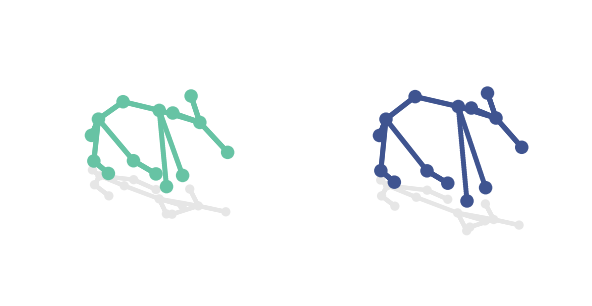

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f2_moseq/a-blscale-examples-simpal.pdf')

In [449]:
fig, ax = plt.subplots(1, 2, figsize = (2, 1), dpi = 150, subplot_kw=dict(projection='3d'))
ax[1].sharex(ax[0])
ax[1].sharey(ax[0])
ax[1].sharez(ax[0])
plotdrop(frame_orig, ax[0], sim_pal['3'], 0.7, 1, shadx=False, shady=False, arms=arms)
plotdrop(frame_scaled, ax[1], sim_pal['52'], 0.7, 1, shadx=False, shady=False, arms=arms)
plotter.finalize(fig, 'a-blscale-examples-simpal')


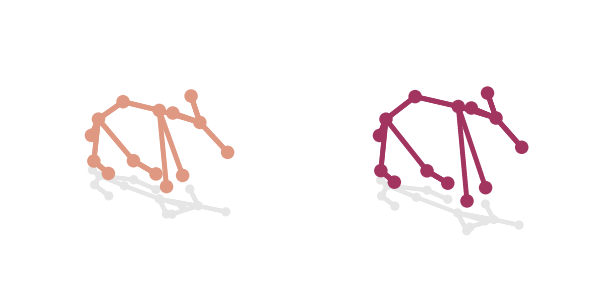

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f2_moseq/a-blscale-examples-agepal.pdf')

In [450]:
fig, ax = plt.subplots(1, 2, figsize = (2, 1), dpi = 150, subplot_kw=dict(projection='3d'))
ax[1].sharex(ax[0])
ax[1].sharey(ax[0])
ax[1].sharez(ax[0])
plotdrop(frame_orig, ax[0], age_pal['3'], 0.7, 1, shadx=False, shady=False, arms=arms)
plotdrop(frame_scaled, ax[1], age_pal['52'], 0.7, 1, shadx=False, shady=False, arms=arms)
plotter.finalize(fig, 'a-blscale-examples-agepal')


### B. moseq syllable example

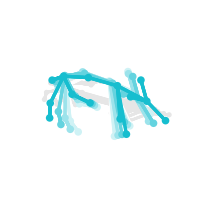

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f2_moseq/syll_ex_1.pdf')

In [52]:
fps=30
sess = "3wk_m0"
ixs = (np.linspace(14.8, 15.6, 5) * fps).astype("int") # for syll_pal[3]
# ixs = (np.linspace(14, 14.8, 5) * fps).astype("int") # for syll_pal[0]
frame_colors = [vu.lighten(syll_pal[3], l) for l in np.linspace(1, 0, len(ixs)) ** 0.8]

# frames is shape (T, n_kpts, 3)
frames = obs_keypts[sess][ixs]

# Generate smooth_frames by fitting and evaluating a polynomial
smooth_frames = lambda frames: np.polyval(
    np.polyfit(
        np.arange(frames.shape[0]), frames.reshape(frames.shape[0], -1), deg=2
    )[:, None],
    np.arange(frames.shape[0])[:, None],
).reshape(frames.shape)
smoothed = smooth_frames(frames)


syll_pal = (sns.color_palette('tab10') * 20)[-4:]

fig = plt.figure(figsize = (1, 1))
axes = [fig.add_subplot(111, projection='3d') for _ in [None] + frames.tolist()]

for ax in axes[:-1]:
    ax.sharex(axes[-1])
    ax.sharey(axes[-1])
    ax.sharex(axes[-1])

for i, f, ax, c in zip(range(len(smoothed)), smoothed, axes[1:], frame_colors):
    plotdrop(f, ax, c, sm=0.5, shadx=False, shady=False, arms=arms, dropax=axes[0])

plotter.finalize(fig, 'a-syll_ex_1')


### A. Bone example 

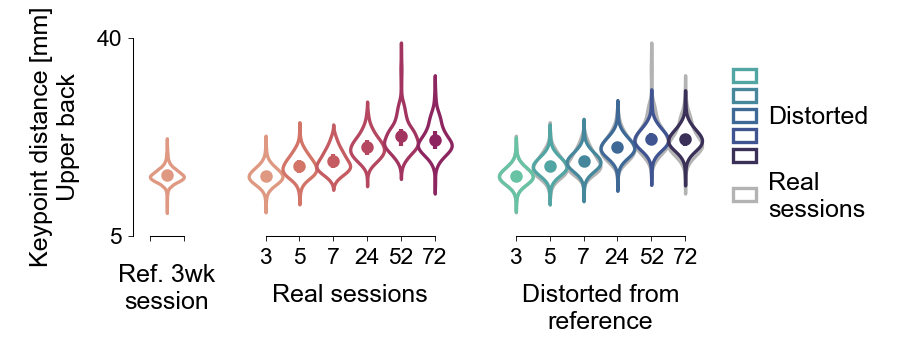

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f2_moseq/a-blscale-quant-example.pdf')

In [26]:
bone_name = 'hi back'
bone_idx = bone_names.index(short_names.inverse[bone_name])
ref_age = '3'
tgt_ages = [a for a in sorted(age_groups.keys(), key = lambda x: int(x)) if a != ref_age]
blscale_age_groups = {
    a: [s for s in blscale_keypoints if re.search(f"{a}bod", s)]
    for a in [ref_age] + tgt_ages
}

_no_out = lambda x: x[abs(x - np.mean(x)) / np.std(x) < 5]
blscale_bls = {
    a: np.concatenate([_bone_lengths(blscale_keypoints[s], arms) for s in g])
    for a, g in blscale_age_groups.items()
}
raw_bls = {
    a: np.concatenate([_bone_lengths(obs_keypts[s], arms) for s in g])
    for a, g in age_groups.items()
}

fig, ax = plt.subplots(1, 3, figsize = (2.5, 1.2), width_ratios = [0.4, 1, 1], dpi=150)

vu.grouped_violins(
    [[_no_out(blscale_bls[ref_age][:, bone_idx])]],
    bw = 0.1,
    ax = ax[0],
    colors = age_pal[ref_age],
    width = 0.1,
    bw_buffer=2,
    jitter=0,
    errorbar_kw={'ms':2},
    error=lambda a: abs(np.quantile(a, [0.25, 0.75], axis=0) - np.mean(a))
)

for a, c, do_err in [
    (ax[1], age_pal, True),
    (ax[2], '.7', False)
]:
    vu.grouped_violins(
        {a: [[_no_out(raw_bls[a][::1000, bone_idx])]] for i, a in enumerate(ages)},
        bw = 1,
        ax = a,
        width = 0.1,
        bw_buffer=2,
        jitter=0,
        colors = c,
        errorbar = do_err,
        errorbar_kw={'ms':2},
        error=lambda a: abs(np.quantile(a, [0.25, 0.75], axis=0) - np.mean(a))
    )

vu.grouped_violins(
    {a: [[_no_out(blscale_bls[a][::1000, bone_idx])]] for i, a in enumerate(ages)},
    bw = 1,
    ax = ax[2],
    colors = sim_pal,
    width = 0.1,
    bw_buffer=2,
    jitter = 0,
    errorbar_kw={'ms':2},
    error=lambda a: abs(np.quantile(a, [0.25, 0.75], axis=0) - np.mean(a))
)

# ax[0].set_xlim(-0.3, 0.3)
ax[0].set_xticks([-0.05, 0.05])
ofs = vu.get_offsets(len(ages))
ax[1].set_xticks(ofs)
ax[1].set_xticklabels(ages)
ax[2].set_xticks(ofs)
ax[2].set_xticklabels(ages)

vu.nticks(ax[0], 2, x = False)
for a in ax:
    a.set_ylim(5, 40)
ax[1].set_yticks([])
ax[2].set_yticks([])

ax[0].set_ylabel(f"Keypoint distance [mm]\nUpper back")
ax[0].set_xlabel(f"Ref. {ref_age}wk\nsession")
ax[1].set_xlabel(f"Real sessions")
ax[2].set_xlabel(f"Distorted from\nreference")

sns.despine(ax = ax[0], trim = True)
sns.despine(ax = ax[1], trim = True, left = True)
sns.despine(ax = ax[2], trim = True, left = True)

fig.tight_layout()
ax[0].set_aspect(vu.get_aspect(ax[1]))
ax[0].set_xlim(-0.1, 0.1)

# handles = [ax[2].plot([np.nan], [np.nan], 'o', ms = 2.5, mew = 0, color = sim_pal[a], label = " ")[0] for a in tgt_ages]
hkw = dict(handleheight=0.5, handlelength=1.)
handles = [ax[2].bar([np.nan], [np.nan], edgecolor = sim_pal[a], fill=None, label = " ")[0] for a in tgt_ages]
# handles_shuf = ax[2].plot([np.nan], [np.nan], 'o', ms = 2.5, mew = 0, color = '.7', label = " ")
handles_shuf = ax[2].bar([np.nan], [np.nan], edgecolor = '.7', fill=None, label = " ")
leg = vu.legend(ax[2], (handles, " " * len(tgt_ages)), loc='center left', bbox_to_anchor = (1.0, 0.6), labelspacing=0, **hkw)
ax[2].text(1.25, 0.6, "Distorted", ha='left', va='center', transform=ax[2].transAxes)
vu.legend(ax[2], (handles_shuf, [" "]), loc='center left', bbox_to_anchor = (1.0, 0.2), labelspacing=0., **hkw)
ax[2].text(1.25, 0.2, "Real\nsessions", ha='left', va='center', transform=ax[2].transAxes)
ax[2].add_artist(leg)

plotter.finalize(fig, 'a-blscale-quant-example', tight = False, despine = False)

#### B. syllable change example

In [236]:
usages.dataset.unique()

array(['3+24+72.5n-m1-s1', '3+24+72.5n-m1-s2', '3+24+72.5n-m1-s3',
       '3+24+72.5n-m2-s1', '3+24+72.5n-m2-s2', '3+24+72.5n-m2-s3',
       '3+24+72.7n-m1-s1', '3+24+72.7n-m1-s2', '3+24+72.7n-m1-s3',
       '3+24+72.7n-m2-s1', '3+24+72.7n-m2-s2', '3+24+72.7n-m2-s3',
       '3+24+72.24n-m1-s1', '3+24+72.24n-m1-s2', '3+24+72.24n-m1-s3',
       '3+24+72.24n-m2-s1', '3+24+72.24n-m2-s2', '3+24+72.24n-m2-s3',
       '3+24+72.52n-m1-s1', '3+24+72.52n-m1-s2', '3+24+72.52n-m1-s3',
       '3+24+72.52n-m2-s1', '3+24+72.52n-m2-s2', '3+24+72.52n-m2-s3',
       '3+24+72.72n-m1-s1', '3+24+72.72n-m1-s2', '3+24+72.72n-m1-s3',
       '3+24+72.72n-m2-s1', '3+24+72.72n-m2-s2', '3+24+72.72n-m2-s3'],
      dtype=object)

In [269]:
window_s = 47
window_s = (window_s, window_s + 3)
fps = 30
window_f = window_s[0] * fps, window_s[1] * fps
s0, d0 = '3wk_3bod_m0', '3+24+72.52n-m1-s1'
s1, d1 = '3wk_52bod_m0', '3+24+72.52n-m1-s2'
s2, d2 = '3wk_3bod_m0', '3+24+72.52n-m1-s2'
ref, nonref = '3', '52'

In [277]:
q_win = f"frame >= {window_f[0]} & frame < {window_f[1]}"
get_query = lambda s, d: f"session == '{s}' & dataset == '{d}'"
get_window = lambda df, w: df.iloc[(df.frame > w[0]).argmax() - 1 : (df.frame > w[1]).argmax()]
on0 = get_window(onsets.query(get_query(s0, d0)), window_f)
on1 = get_window(onsets.query(get_query(s1, d1)), window_f)
on2 = get_window(onsets.query(get_query(s2, d2)), window_f)
win_sylls = np.unique(np.concatenate([on0.syllable, on1.syllable, on2.syllable])).tolist()
syll_pal = (sns.color_palette('tab20') * 20)[-len(win_sylls):]


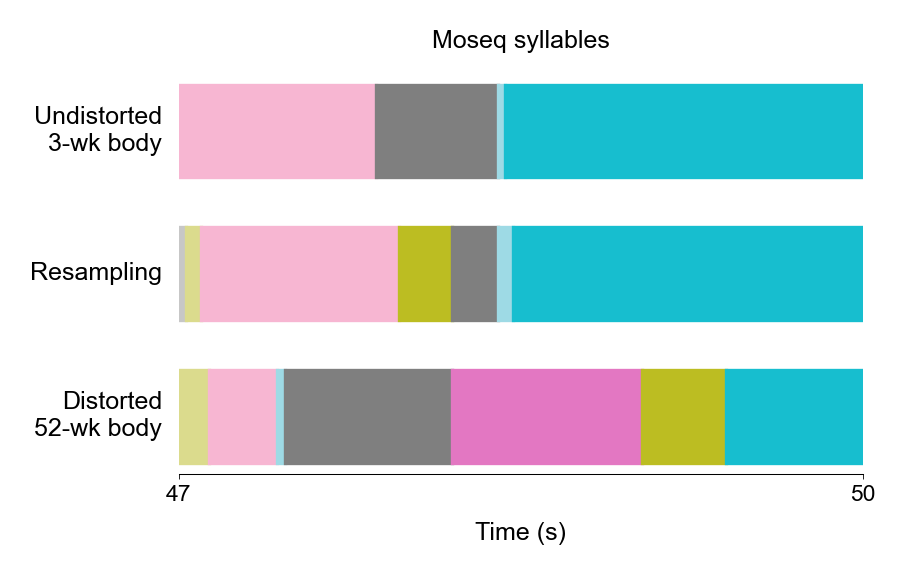

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f2_moseq/syllable-timecourses.pdf')

In [279]:
fig, ax = plt.subplots(3, 1, figsize = (3, 1.9), sharey = True, dpi=150)
for a, on in zip(ax, [on0, on2, on1]):
    for _, row in on.iterrows():
        s, e = row.frame / fps, (row.frame + row.duration) / fps
        i = win_sylls.index(row.syllable)
        a.add_artist(plt.Rectangle((s, 0 - 0.4), e - s, 0.8, color = syll_pal[i]))
for a in ax:
    vu.axes_off(a)
    a.set_xlim(window_s[0], window_s[1])
    a.set_ylim(-0.5, 0.5)
ax[2].spines['bottom'].set_visible(True)
vu.nticks(ax[2], 2, y = False)
ax[2].set_xlabel("Time (s)")
ax[0].set_ylabel(f"Undistorted\n{ref}-wk body", ha = 'right', rotation = 0, va = 'center')
ax[2].set_ylabel(f"Distorted\n{nonref}-wk body", ha = 'right', rotation = 0, va = 'center')
ax[1].set_ylabel(f"Resampling", ha = 'right', rotation = 0, va = 'center')
ax[0].set_title("Moseq syllables")
plotter.finalize(fig, 'syllable-timecourses', despine = False)


### C. Syllable usage for two sessions

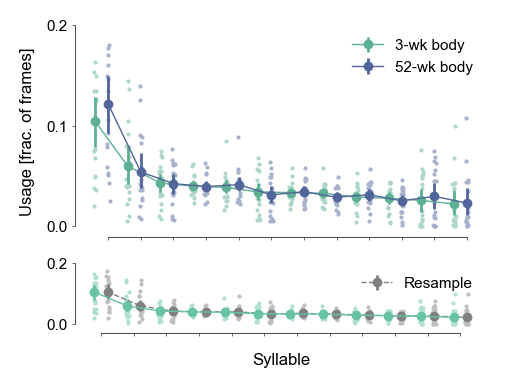

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f2_moseq/single-pair-usage-diffs.pdf')

In [369]:
u01 = usages.query("dataset == @d0")
u2 = usages.query("dataset == @d2")

fig, ax = plt.subplots(2, 1, figsize=(2.5, 1.9), height_ratios=[3, 1])

u_pivot = usage_pivot(u01, ("session", "body"), thresh=(0.037, 0.2, None, 0))
body_groupby = u_pivot.groupby("body")
u_pivot = u_pivot[body_groupby.mean().loc[ref].sort_values(ascending = False).index]
body_groupby = u_pivot.groupby("body")

u2_pivot = u2.pivot(columns="index", values="usage", index=("session", "body"))[
    u_pivot.columns
]
u2_pivot = u2_pivot.groupby("body").get_group(ref)
darken = lambda c, f: np.array(mpl_col.to_rgba(c)) * (1 - f) + np.array(mpl_col.to_rgba('k')) * f
tmp_sim_pal = {
    '3': darken(sim_pal['3'], 0.1),
    '52': vu.lighten(sim_pal['52'], 0.1)
}

kws = dict(
    xticks="",
    lighten_points=0.5,
    errorbar_kw=dict(fmt="o-", lw=0.5, ms = 2.5),
    points_kw=dict(ms=1.5, mew=0, zorder=-2),
    error=lambda a: vu.ci(a, level=0.95, n=1000)
)
for ofs, (b, b_usage) in zip([-0.2, 0.2], body_groupby):
    vu.grouped_stripplot(
        {b: b_usage.values.T},
        ax=ax[0],
        x = np.arange(len(b_usage.values.T)) + ofs,
        colors=tmp_sim_pal,
        labels={ref: f"{ref}-wk body", nonref: f"{nonref}-wk body"},
        legend = False,
        **kws
    )
    vu.legend(ax[0], loc = 'upper right', bbox_to_anchor = None)


vu.grouped_stripplot(
    {'seed': u2_pivot.values.T},
    x = np.arange(len(u_pivot.columns)) + 0.2,
    ax=ax[1],
    colors='.5',
    labels = {'seed': 'Resample'},
    legend = False,
    **{**kws, 'errorbar_kw': dict(fmt='o--', lw=0.5, ms = 2.5)}
)

vu.grouped_stripplot(
    {ref: body_groupby.get_group(ref).values.T},
    x = np.arange(len(u_pivot.columns)) - 0.2,
    ax=ax[1],
    colors=sim_pal,
    **kws
)
ax[1].set_xticks(np.arange(len(u_pivot.columns)))
vu.legend(ax[1], loc = 'upper right', bbox_to_anchor = None)


ax[0].set_ylim(-0.01, 0.2)
ax[0].set_yticks([0, 0.1, 0.2])
ax[1].set_ylim(-0.03, 0.2)
ax[1].set_yticks([0, 0.2])
sns.despine(ax=ax[0], trim=True)
sns.despine(ax=ax[1], trim=True)

ax[1].set_xlabel("Syllable")
ax[0].set_ylabel("Usage [frac. of frames]")

plotter.finalize(fig, 'single-pair-usage-diffs')

### D. LogFCs across ages

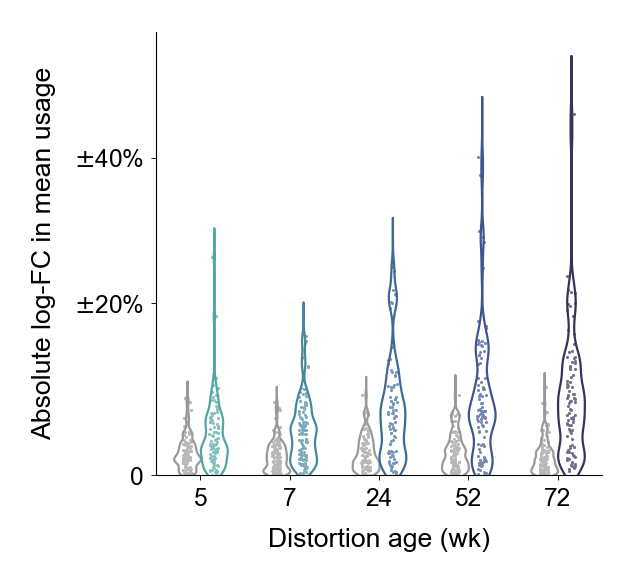

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f2_moseq/d-logfc.pdf')

In [367]:
src, ref, tgt_ages, norm = ("3+24+72", "3", ["5", "7", "24", "52", "72"], "n"
)
first_seed = 1
second_seeds = [2, 3]
models = "12"


kw = lambda ms: dict(
    errorbar = False,
    width = 0.3,
    jitter = 0,
    offset = False,
    lighten_points = 0.3,
    points = True,
    points_kw = {'ms': ms, 'mew': 0, 'zorder': -3},
    legend = False,
    point_jitter=0.05,
    fill_kw=dict(lw=0.5),
    bw_buffer=5,
)

safe_log = lambda x: np.log(x, where=x > 0, out=np.full_like(x, np.nan))

fig, ax = plt.subplots(1, 1, figsize = (1.8, 1.8), dpi = 160)
for tgt in tgt_ages:
    
    reseed_logfc = []
    reseed_logfc_indiv = []
    morph_logfc = []
    morph_logfc_indiv = []
    for second_seed in second_seeds:
        for model in models:
            dset_root = f"{src}.{tgt}{norm}-m{model}"
            ref_s0, ref_s1, tgt_s1 = get_target_comparison_pivots(
                usages, dset_root, src, ref, tgt, first_seed, second_seed
            )
            ref_s0 = np.where(ref_s0.values < 1e-8, np.nan, ref_s0)
            ref_s1 = np.where(ref_s1.values < 1e-8, np.nan, ref_s1)
            tgt_s1 = np.where(tgt_s1.values < 1e-8, np.nan, tgt_s1)

            reseed_logfc.append(abs(safe_log(ref_s1.mean(axis = 0) / ref_s0.mean(axis = 0))))
            # reseed_logfc_indiv.append(abs(safe_log(ref_s1 / ref_s0).ravel()))
            morph_logfc.append(abs(safe_log(tgt_s1.mean(axis = 0) / ref_s0.mean(axis = 0))))
            # morph_logfc_indiv.append(abs(safe_log(tgt_s1 / ref_s0).ravel()))

    x = tgt_ages.index(tgt)
    for a, x_ofs, arr, clr, ms in [
        # (ax, -0.15, reseed_logfc_indiv, '.7', 0.7),
        # (ax,  0.15, morph_logfc_indiv, sim_pal[tgt], 0.7),
        (ax, -0.15, reseed_logfc, '.6', 0.7),
        (ax,  0.15, morph_logfc, sim_pal[tgt], 0.7)
    ]:
        arr = np.concatenate(arr).ravel()
        arr = arr[np.isfinite(arr)]
        vmax = np.percentile(arr, 80)
        vu.grouped_violins(
            [[arr]],
            bw = vmax / 10,
            x = [x + x_ofs],
            ax = a,
            colors = clr,
            **kw(ms)
        )
    
ax.set_xticks(np.arange(len(tgt_ages)))
ax.set_xticklabels(tgt_ages)

ax.set_xlim(-0.5, len(tgt_ages) - 1 + 0.5)
ax.set_ylim(-0.0, None)
ax.set_yticks([0, np.log(1.2), np.log(1.4)])
ax.set_yticklabels([0, "$\pm$20%", "$\pm$40%"])
    
ax.set_ylabel("Absolute log-FC in mean usage")
ax.set_xlabel("Distortion age (wk)")

plotter.finalize(fig, 'd-logfc', tight=False)

### E. Population JSDs

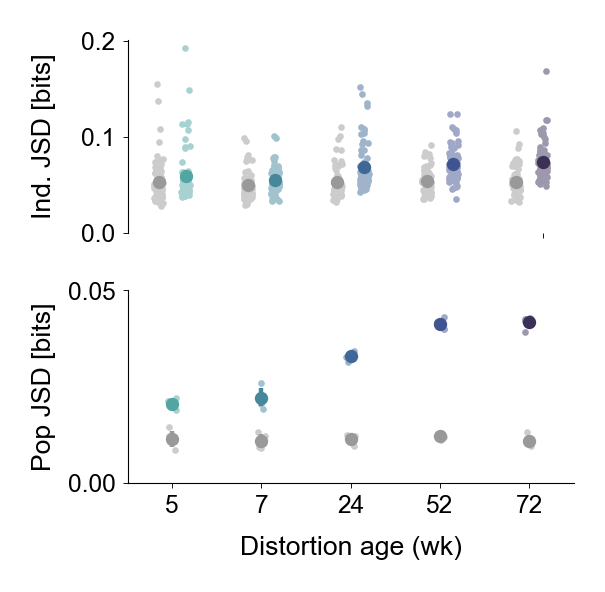

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f2_moseq/e-jsd.pdf')

In [366]:
src, ref, tgt_ages, norm, models = "3+24+72", "3", ["5", "7", "24", "52", "72"], "n", "12"
first_seed = 1
second_seeds = [2, 3]

kws = dict(
    xticks="",
    lighten_points=0.5,
    errorbar_kw=dict(fmt="o", ms = 3, mew=0),
    points_kw=dict(ms=1.5, mew=0),
    legend=False,
    error=lambda a: vu.ci(a, level=0.95, n=1000)
)

jsd = lambda x, y: [
    distance.jensenshannon(x.mean(axis = 0), y.mean(axis = 0), base=2),
    [distance.jensenshannon(x_, y_, base=2) for x_, y_ in zip(x, y)]
]


fig, ax = plt.subplots(2, 1, figsize = (1.8, 1.8), dpi = 160, gridspec_kw=dict(hspace=0.3))
for tgt in tgt_ages:
    ref_ref_jsd = {"ind": [], "pop": []}
    ref_tgt_jsd = {"ind": [], "pop": []}

    for model in models:
        for second_seed in second_seeds:
            dset_root = f"{src}.{tgt}{norm}-m{model}"
            ref_s0, ref_s1, tgt_s1 = get_target_comparison_pivots(
                usages, dset_root, src, ref, tgt, first_seed, second_seed)

            ref_ref = jsd(ref_s0.values, ref_s1.values)
            ref_ref_jsd['pop'].append(ref_ref[0])
            ref_ref_jsd['ind'].extend(ref_ref[1])

            ref_tgt = jsd(ref_s0.values, tgt_s1.values)
            ref_tgt_jsd['pop'].append(ref_tgt[0])
            ref_tgt_jsd['ind'].extend(ref_tgt[1])

    x = tgt_ages.index(tgt)
    for a, x_ofs, arr, clr in [
        (ax[0], -0.15, ref_ref_jsd['ind'], '.6'),
        (ax[0],  0.15, ref_tgt_jsd['ind'], sim_pal[tgt]),
        (ax[1], -0, ref_ref_jsd['pop'], '.6'),
        (ax[1],  0, ref_tgt_jsd['pop'], sim_pal[tgt])
    ]:
        arr = np.array(arr).ravel()
        
        vu.grouped_stripplot(
            [arr],
            x = [x + x_ofs],
            ax = a,
            colors = clr,
            **kws,
        )
    
ax[1].set_xticks(np.arange(len(tgt_ages)))
ax[1].set_xticklabels(tgt_ages)
for a in ax:
    a.set_xlim(-0.5, len(tgt_ages) - 1 + 0.5)
    a.set_ylim(-0.0, None)
ax[1].set_yticks([0, 0.05])
ax[0].spines['bottom'].set_visible(False)


fig.text(-0.02, 0.5, "Ind. JSD [bits]", rotation = 90, va = 'center', ha='center',
    transform=mpl.transforms.blended_transform_factory(fig.transFigure, ax[0].transAxes))
fig.text(-0.02, 0.5, "Pop JSD [bits]", rotation = 90, va = 'center', ha='center',
    transform=mpl.transforms.blended_transform_factory(fig.transFigure, ax[1].transAxes))
ax[1].set_xlabel("Distortion age (wk)")
# ax[0].set_ylabel("Ind. JSD [bits]")
# ax[1].set_ylabel("Pop. JSD")

plotter.finalize(fig, 'e-jsd', tight=False, despine=False)

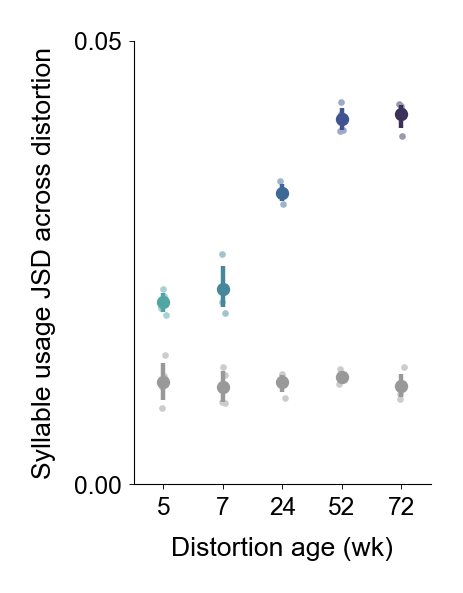

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f2_moseq/e-jsd-pop.pdf')

In [24]:
src, ref, tgt_ages, norm, models = "3+24+72", "3", ["5", "7", "24", "52", "72"], "n", "12"
first_seed = 1
second_seeds = [2, 3]

kws = dict(
    xticks="",
    lighten_points=0.5,
    errorbar_kw=dict(fmt="o", ms = 3, mew=0),
    points_kw=dict(ms=1.5, mew=0),
    legend=False,
    error=lambda a: vu.ci(a, level=0.95, n=1000)
)

jsd = lambda x, y: [
    distance.jensenshannon(x.mean(axis = 0), y.mean(axis = 0), base=2),
    [distance.jensenshannon(x_, y_, base=2) for x_, y_ in zip(x, y)]
]


fig, ax = plt.subplots(1, 1, figsize = (1.2, 1.8), dpi = 160, gridspec_kw=dict(hspace=0.3))
for tgt in tgt_ages:
    ref_ref_jsd = {"ind": [], "pop": []}
    ref_tgt_jsd = {"ind": [], "pop": []}

    for model in models:
        for second_seed in second_seeds:
            dset_root = f"{src}.{tgt}{norm}-m{model}"
            ref_s0, ref_s1, tgt_s1 = get_target_comparison_pivots(
                usages, dset_root, src, ref, tgt, first_seed, second_seed)

            ref_ref = jsd(ref_s0.values, ref_s1.values)
            ref_ref_jsd['pop'].append(ref_ref[0])
            ref_ref_jsd['ind'].extend(ref_ref[1])

            ref_tgt = jsd(ref_s0.values, tgt_s1.values)
            ref_tgt_jsd['pop'].append(ref_tgt[0])
            ref_tgt_jsd['ind'].extend(ref_tgt[1])

    x = tgt_ages.index(tgt)
    for a, x_ofs, arr, clr in [
        # (ax, -0.15, ref_ref_jsd['ind'], '.6'),
        # (ax,  0.15, ref_tgt_jsd['ind'], sim_pal[tgt]),
        (ax, -0, ref_ref_jsd['pop'], '.6'),
        (ax,  0, ref_tgt_jsd['pop'], sim_pal[tgt])
    ]:
        arr = np.array(arr).ravel()
        
        vu.grouped_stripplot(
            [arr],
            x = [x + x_ofs],
            ax = a,
            colors = clr,
            **kws,
        )
    
ax.set_xticks(np.arange(len(tgt_ages)))
ax.set_xticklabels(tgt_ages)

ax.set_xlim(-0.5, len(tgt_ages) - 1 + 0.5)
ax.set_ylim(-0.0, None)
ax.set_yticks([0, 0.05])


# fig.text(-0.02, 0.5, "Ind. JSD [bits]", rotation = 90, va = 'center', ha='center',
#     transform=mpl.transforms.blended_transform_factory(fig.transFigure, ax.transAxes))
# fig.text(-0.02, 0.5, "Pop JSD [bits]", rotation = 90, va = 'center', ha='center',
#     transform=mpl.transforms.blended_transform_factory(fig.transFigure, ax.transAxes))
ax.set_ylabel("Syllable usage JSD across distortion")
ax.set_xlabel("Distortion age (wk)")
# ax.set_ylabel("Ind. JSD [bits]")
# ax.set_ylabel("Pop. JSD")

plotter.finalize(fig, 'e-jsd-pop', tight=False, despine=False)

#### F. Classifiers

In [375]:
def arrays_to_feats_labels(*Xs):
    """
    Xs : list[array (n_samples, n_feats)]
    """
    labels = np.concatenate([np.full(len(X), i) for i, X in enumerate(Xs)])
    X = np.concatenate(Xs)
    return X, labels

def directional_classifier(trn0, trn1, val0, val1, alphas, classifier_kws = {}, n_null = 0, null_seed = 0):
    
    X, y = arrays_to_feats_labels(trn0, trn1)
    scores = []
    null_scores = [[] for _ in alphas]
    for i, alpha in enumerate(alphas):
        kws = dict(C = 1 / alpha, **classifier_kws)
        clf = LogisticRegression(**kws).fit(X, y)
        scores.append(
            (clf.predict_proba(val1) - clf.predict_proba(val0))[0, 1]
        )
    
        rng = np.random.default_rng(null_seed)
        for _ in range(n_null):
            clf = LogisticRegression(**kws).fit(X, rng.permutation(y))
            null_scores[i].append((clf.predict_proba(val1) - clf.predict_proba(val0))[0, 1])
    return scores, null_scores


def run_heldout_directional(arr0, arr1, alphas, classifier_kws, progress=False):
    dset_scores = []
    pbar = tqdm.trange if progress else range
    for i_holdout in pbar(len(arr0)):
        holdin = list(range(i_holdout)) + list(range(i_holdout + 1, len(arr0)))
        trn0 = arr0[holdin]
        trn1 = arr1[holdin]
        val0 = arr0[[i_holdout]]
        val1 = arr1[[i_holdout]]
        
        scores, _ = directional_classifier(
            trn0, trn1, val0, val1,
            alphas, dict(**classifier_kws, random_state=i_holdout),
            n_null=0,
        )
        for a, s in zip(alphas, scores):
            dset_scores.append(dict(score=s, acc = s > 0, alpha=a, holdout=i, **meta))

    dset_scores = pd.DataFrame(dset_scores)
    best_alpha = dset_scores.groupby("alpha").acc.mean()[::-1].idxmax()
    return best_alpha, dset_scores
    

In [379]:
(src, ref, tgt_ages, norm, models) = "3+24+72", "3", ["5", "7", "24", "52", "72"], "n", "12"
first_seed = 1
second_seeds = [2, 3]
models = "12"

alphas = [1e-3]
classifier_kws = dict(
    max_iter=1000,
    solver="liblinear",
    class_weight="balanced",
    penalty="l1",
)

classif_data = {
    a: {k: [] for k in ["ref_ref_acc", "ref_tgt_acc", "ref_ref_auc", "ref_tgt_auc"]}
    for a in tgt_ages
}

with tqdm(total=len(tgt_ages) * len(models) * len(second_seeds)) as pbar:
    for tgt in tgt_ages:

        for model in models:
            for second_seed in second_seeds:
                dset_root = f"{src}.{tgt}{norm}-m{model}"
                ref_s0, ref_s1, tgt_s1 = get_target_comparison_pivots(
                    usages, dset_root, src, ref, tgt, first_seed, second_seed)

                best_alpha, scores = run_heldout_directional(
                    ref_s0.values, ref_s1.values, alphas, classifier_kws, progress=False)
                best_score = scores.groupby("alpha").get_group(best_alpha)
                classif_data[tgt]['ref_ref_acc'].append(best_score.acc.mean())
                auc = metrics.roc_auc_score(np.concatenate([np.zeros(len(ref_s0)), np.ones(len(ref_s0))]), np.concatenate([-best_score.score, best_score.score]))
                classif_data[tgt]['ref_ref_auc'].append(auc)

                best_alpha, scores = run_heldout_directional(
                    ref_s0.values, tgt_s1.values, alphas, classifier_kws, progress=False)
                best_score = scores.groupby("alpha").get_group(best_alpha)
                classif_data[tgt]['ref_tgt_acc'].append(best_score.acc.mean())
                auc = metrics.roc_auc_score(np.concatenate([np.zeros(len(ref_s0)), np.ones(len(ref_s0))]), np.concatenate([-best_score.score, best_score.score]))
                classif_data[tgt]['ref_tgt_auc'].append(auc)

                pbar.update(1)


100%|██████████| 20/20 [00:28<00:00,  1.41s/it]


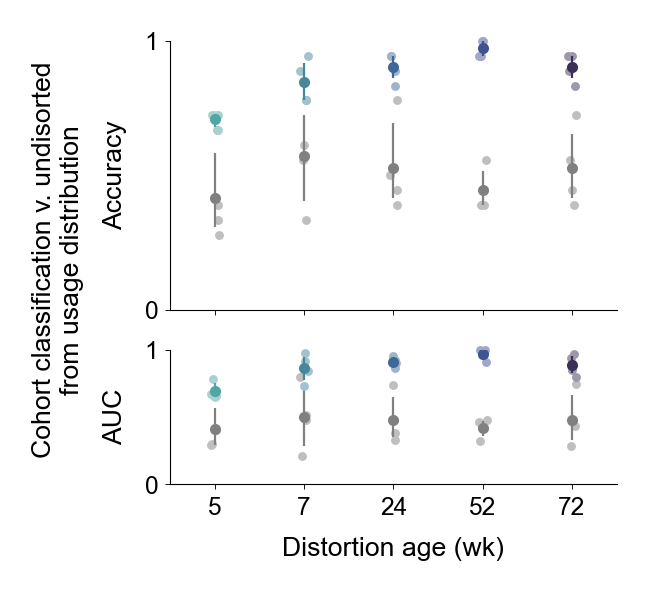

PosixPath('/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f2_moseq/f-classif.pdf')

In [400]:


kws = dict(
    xticks="",
    lighten_points=0.5,
    errorbar_kw=dict(fmt="o", ms = 2.5, elinewidth = 0.5, mew=0),
    points_kw=dict(ms=2, mew=0, clip_on=False),
    legend=False,
    error=lambda a: vu.ci(a, level=0.95, n=1000)
)

fig, ax = plt.subplots(2, 1, height_ratios=[2, 1], sharex=True, figsize = (1.8, 1.8), dpi = 160)


for tgt in tgt_ages:

    x = tgt_ages.index(tgt)
    for a, x_ofs, arr, clr in [
        (ax[0], -0, classif_data[tgt]['ref_ref_acc'], '.5'),
        (ax[0],  0, classif_data[tgt]['ref_tgt_acc'], sim_pal[tgt]),
        (ax[1], -0, classif_data[tgt]['ref_ref_auc'], '.5'),
        (ax[1],  0, classif_data[tgt]['ref_tgt_auc'], sim_pal[tgt]),
    ]:
        arr = np.array(arr).ravel()
        vu.grouped_stripplot(
            [arr],
            x = [x + x_ofs],
            ax = a,
            colors = clr,
            **kws,
        )

ax[1].set_xticks(np.arange(len(tgt_ages)))
ax[1].set_xticklabels(tgt_ages)
for a in ax:
    a.set_xlim(-0.5, len(tgt_ages) - 1 + 0.5)
    a.set_ylim(0, 1)
    a.set_yticks([0, 1])

fig.text(-0.07, 0.5, "Cohort classification v. undisorted\nfrom usage distribution", rotation = 90, va = 'center', ha='center')
ax[0].set_ylabel("Accuracy")
ax[1].set_ylabel("AUC")
ax[1].set_xlabel("Distortion age (wk)")

plotter.finalize(fig, 'f-classif', tight=False)
